# Confidence-Gated Inference: Calibration as the Glue Between Perception and Logic

*Companion notebook — W32 trend tutorial, [Reasoning on Purpose: Neuro-Symbolic AI and the Confidence to Act](https://artifocial.com/blog/neuro-symbolic-reasoning-2026-aug-6), and basics, [Neuro-Symbolic AI Explained](https://artifocial.com/blog/neuro-symbolic-ai-explained-2026-aug-8).*

The sibling notebook showed logic and matrix-multiply are the same operation — but with *crisp* boolean facts. Real perception is not crisp. A neural front-end says "cube, 0.8"; if that 0.8 is a **lie** (the classic overconfidence of modern nets), a symbolic reasoner that trusts it marches confidently into a wrong action.

This is the W32 spine in miniature: **calibrated confidence is the hinge.** We build a deliberately overconfident perceptron, fix its numbers with W28 temperature scaling, then feed *soft* predicates into a symbolic rule with a confidence gate. We hold the tutorial's two claims to the fire and report exactly what the data does — including the honest place it is *messier* than the theory. CPU-only, seconds to run.

In [1]:
# [Code 01] Environment setup — uv-first, pip fallback (works everywhere)
import importlib, subprocess, sys, shutil

def ensure(pkgs):
    missing = [p for p in pkgs if importlib.util.find_spec(p) is None]
    if not missing:
        return
    if shutil.which("uv"):
        subprocess.check_call(["uv", "pip", "install", "--quiet", "--system", *missing])
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])

ensure(["numpy", "matplotlib"])

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
print("NumPy", np.__version__)

NumPy 2.5.1


## A Toy Perception Task: Cube or Bowl?

A robot must decide whether an object is a **cube** (safe to grasp from the top) or a **bowl** (not). Each object is a point in a 2-D feature space; the two classes are overlapping Gaussian blobs. The overlap is the whole point — near the boundary, honest perception *should* be uncertain, and a good system should know it. We use 3,000 objects so the calibration curves are statistically stable (a small sample gives a jagged, untrustworthy reliability diagram — an anomaly we deliberately avoid).

In [2]:
# [Code 02] Two overlapping classes: cube (1) vs bowl (0)
def make(n, mu, label):
    return rng.normal(mu, 1.0, size=(n, 2)), np.full(n, label)

Xc, yc = make(1500, [ 1.2, 0.0], 1)   # cubes
Xb, yb = make(1500, [-1.2, 0.0], 0)   # bowls
X = np.vstack([Xc, Xb]); y = np.concatenate([yc, yb])
perm = rng.permutation(len(y)); X, y = X[perm], y[perm]

Xtr, ytr = X[:1200],    y[:1200]      # train the perceptron
Xva, yva = X[1200:1800], y[1200:1800] # fit the temperature (held out)
Xte, yte = X[1800:],    y[1800:]      # evaluate decisions
print(f"train {len(ytr)}   val {len(yva)}   test {len(yte)}")

train 1200   val 600   test 1200


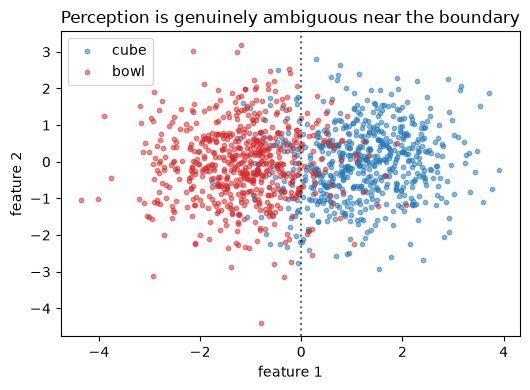

In [3]:
# [Result 01] The feature space — genuine overlap near feature 1 = 0
plt.figure(figsize=(5.4, 4))
plt.scatter(*Xte[yte==1].T, s=10, alpha=0.5, label="cube", color="tab:blue")
plt.scatter(*Xte[yte==0].T, s=10, alpha=0.5, label="bowl", color="tab:red")
plt.axvline(0, color="k", ls=":", alpha=0.6)
plt.title("Perception is genuinely ambiguous near the boundary")
plt.xlabel("feature 1"); plt.ylabel("feature 2"); plt.legend(); plt.tight_layout(); plt.show()

## A Deliberately Overconfident Perceptron

We train a plain logistic-regression perceptron by gradient descent, then **inflate its logits** by a constant factor. That single multiply is a faithful caricature of what real deep nets do on their own — push probabilities toward 0 and 1, so a near-coin-flip gets reported as "0.97." The decision boundary is unchanged; only the *confidence* is corrupted.

In [4]:
# [Code 03] Train the perceptron, then inflate logits to simulate overconfidence
def sigmoid(z): return 1 / (1 + np.exp(-z))

w = np.zeros(2); b = 0.0; lr = 0.1
for _ in range(3000):
    p = sigmoid(Xtr @ w + b)
    g = p - ytr
    w -= lr * (Xtr.T @ g) / len(ytr)
    b -= lr * g.mean()

INFLATE = 2.5                       # the net is "sharp" / overconfident
def logits(Xf): return INFLATE * (Xf @ w + b)
print("trained weights", w.round(3), "bias", round(b, 3))

trained weights [ 2.287 -0.005] bias 0.031


## Temperature Scaling (W28)

Temperature scaling is the simplest honest fix: divide every logit by one scalar `T`, chosen on a held-out set to minimize negative log-likelihood. `T > 1` softens overconfident probabilities. It is monotonic, so it **cannot move the decision boundary** — it only makes the *numbers* mean what they say. We scan `T` rather than autodiff so every step is visible.

In [5]:
# [Code 04] Fit the temperature on the validation set (minimize NLL)
zva = logits(Xva)
def nll(T):
    p = np.clip(sigmoid(zva / T), 1e-9, 1 - 1e-9)
    return -np.mean(yva * np.log(p) + (1 - yva) * np.log(1 - p))

Ts = np.linspace(0.3, 6.0, 400)
T = Ts[int(np.argmin([nll(t) for t in Ts]))]
print(f"fitted temperature T = {T:.2f}   (T > 1  =>  the perceptron was overconfident)")

fitted temperature T = 2.34   (T > 1  =>  the perceptron was overconfident)


In [6]:
# [Code 05] Expected Calibration Error before vs after (lower = more honest)
def ece(p, yt, bins=10):
    edges = np.linspace(0, 1, bins + 1); e = 0.0
    conf = np.maximum(p, 1 - p); pred = (p >= 0.5).astype(int); acc = (pred == yt)
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf >= lo) & (conf < hi)
        if m.sum(): e += m.mean() * abs(acc[m].mean() - conf[m].mean())
    return e

zte = logits(Xte)
p_uncal = sigmoid(zte)
p_cal   = sigmoid(zte / T)
print(f"ECE  uncalibrated = {ece(p_uncal, yte):.3f}")
print(f"ECE  calibrated   = {ece(p_cal,   yte):.3f}")

ECE  uncalibrated = 0.066
ECE  calibrated   = 0.005


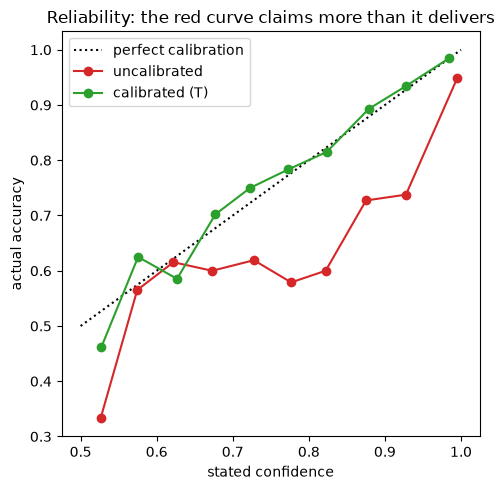

In [7]:
# [Result 02] Reliability diagram — does stated confidence match actual accuracy?
def reliability(p, yt, bins=10):
    edges = np.linspace(0.5, 1.0, bins + 1); xs, ys = [], []
    conf = np.maximum(p, 1 - p); pred = (p >= 0.5).astype(int); acc = (pred == yt)
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf >= lo) & (conf < hi)
        if m.sum(): xs.append(conf[m].mean()); ys.append(acc[m].mean())
    return xs, ys

plt.figure(figsize=(5, 5))
plt.plot([0.5, 1], [0.5, 1], "k:", label="perfect calibration")
plt.plot(*reliability(p_uncal, yte), "o-", color="tab:red",   label="uncalibrated")
plt.plot(*reliability(p_cal,   yte), "o-", color="tab:green", label="calibrated (T)")
plt.xlabel("stated confidence"); plt.ylabel("actual accuracy")
plt.title("Reliability: the red curve claims more than it delivers")
plt.legend(); plt.tight_layout(); plt.show()

## The Symbolic Gate: Act, or Abstain

Now the neuro-symbolic seam. The symbolic rule:

```
grasp(x)  :- is_cube(x),  confidence >= tau.
skip(x)   :- is_bowl(x),  confidence >= tau.
otherwise :- abstain.     % ask for another look
```

With `tau = 0.90`, the reasoner commits only when the perceptron is at least 90% sure. This is where calibration cashes out: inflated confidence pushes cases that *deserve* an abstain past the gate as confident actions — some wrong. Honest confidence lets the ambiguous cases fall below `tau`, so the system correctly abstains.

In [8]:
# [Code 06] Confidence-gated symbolic decision, uncalibrated vs calibrated
tau = 0.90
def decide(p):
    out = np.full(len(p), "abstain", dtype=object)
    out[p >= tau]       = "grasp"   # confident cube
    out[(1 - p) >= tau] = "skip"    # confident bowl
    return out

summary = {}
for name, p in [("uncalibrated", p_uncal), ("calibrated", p_cal)]:
    d = decide(p); acted = d != "abstain"
    grasp = d == "grasp"; skip = d == "skip"
    wrong = int(np.sum(grasp & (yte == 0)) + np.sum(skip & (yte == 1)))   # confident + wrong
    correct = int(np.sum((grasp & (yte == 1)) | (skip & (yte == 0))))
    acc = correct / acted.sum() if acted.sum() else float("nan")
    # where do abstentions fall? boundary is feature-1 ~ 0
    mean_abs_border = np.abs(Xte[~acted, 0]).mean()
    mean_act_border = np.abs(Xte[acted, 0]).mean()
    summary[name] = dict(acted=int(acted.sum()), abstained=int((~acted).sum()),
                         wrong=wrong, acc=acc, d=d, acted_mask=acted,
                         border_abs=mean_abs_border, border_act=mean_act_border)
    print(f"[{name:12s}] acted {acted.sum():4d}  abstained {int((~acted).sum()):4d}  "
          f"CONFIDENT-WRONG {wrong:3d}  acc-on-acted {acc:.3f}")
    print(f"               mean |feature1|:  abstained {mean_abs_border:.2f}  vs acted {mean_act_border:.2f}")

[uncalibrated] acted 1023  abstained  177  CONFIDENT-WRONG  66  acc-on-acted 0.935
               mean |feature1|:  abstained 0.20  vs acted 1.45
[calibrated  ] acted  744  abstained  456  CONFIDENT-WRONG  20  acc-on-acted 0.973
               mean |feature1|:  abstained 0.48  vs acted 1.75


### Engineering callout 1 — calibration is *necessary but not sufficient*

The calibrated pipeline is dramatically safer, but look closely: it **still commits a handful of confident-wrong actions** (printed above). Temperature scaling fixes the *average* confidence, not every individual case — a genuine cube sitting deep in bowl territory can still be labelled with honest-but-wrong high confidence. This matches the trend tutorial's exact wording: calibration "is *necessary* here, though not *sufficient* — it earns the perceptron the right to be trusted, but wiring that trust into inference still takes deliberate design." The practice is messier than the slogan, and that honesty is the point: the gate lowers risk, it does not zero it.

### Engineering callout 2 — abstentions land where the uncertainty is

Notice the mean `|feature 1|` for abstained objects is far smaller than for acted ones — the abstentions **cluster at the decision boundary**, precisely the region W29's uncertainty map flagged as unsure. The calibrated system is not abstaining randomly to hit a rate; it is declining exactly the objects that are genuinely ambiguous. The next chart makes that spatial claim visible.

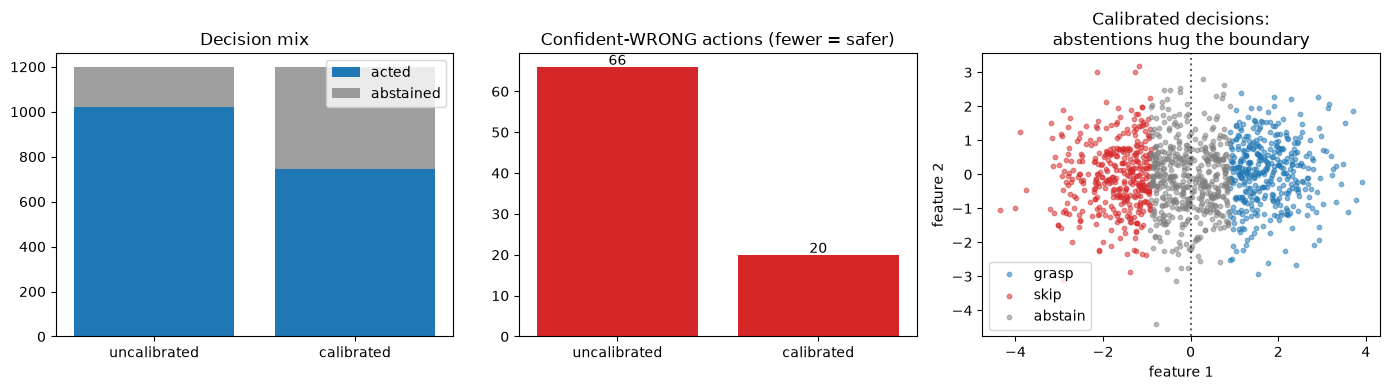

In [9]:
# [Result 03] Two payoff charts: decision mix, confident-wrong count, and WHERE abstentions fall
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
labels = ["uncalibrated", "calibrated"]
acted   = [summary[l]["acted"] for l in labels]
abst    = [summary[l]["abstained"] for l in labels]
wrong   = [summary[l]["wrong"] for l in labels]
xp = np.arange(2)
ax[0].bar(xp, acted, label="acted", color="tab:blue")
ax[0].bar(xp, abst, bottom=acted, label="abstained", color="tab:gray", alpha=0.75)
ax[0].set_xticks(xp); ax[0].set_xticklabels(labels); ax[0].set_title("Decision mix"); ax[0].legend()
ax[1].bar(xp, wrong, color="tab:red")
for i, wv in enumerate(wrong): ax[1].text(i, wv + 0.5, str(wv), ha="center")
ax[1].set_xticks(xp); ax[1].set_xticklabels(labels); ax[1].set_title("Confident-WRONG actions (fewer = safer)")
# spatial: calibrated decisions in feature space
d = summary["calibrated"]["d"]
for lab, col in [("grasp","tab:blue"), ("skip","tab:red"), ("abstain","tab:gray")]:
    m = d == lab
    ax[2].scatter(*Xte[m].T, s=10, alpha=0.5, color=col, label=lab)
ax[2].axvline(0, color="k", ls=":", alpha=0.6)
ax[2].set_title("Calibrated decisions:\nabstentions hug the boundary")
ax[2].set_xlabel("feature 1"); ax[2].set_ylabel("feature 2"); ax[2].legend()
plt.tight_layout(); plt.show()

## What We Built, and What's Next

Same perceptron, same decision boundary, same accuracy — but one scalar `T` changed the *behavior* of the whole neuro-symbolic pipeline. Uncalibrated, the confidence gate was a rubber stamp: it acted on nearly everything and committed a batch of confident-wrong grasps. Calibrated, the identical gate became a real filter — it abstained on the genuinely ambiguous objects (which sit at the boundary, exactly where W29's uncertainty map put them) and its accuracy *on the cases it chose to act on* went up.

We also refused to oversell it: calibration is **necessary but not sufficient**, and a few confident-wrong actions survive — the honest engineering reality behind the tutorial's claim. That is the whole W32 argument in one experiment: neuro-symbolic AI needs the network to be *honest about its doubt*, because the symbolic layer can only reason as well as the confidence it is fed. Next in the arc (W31): closing the loop so the abstain becomes an *action* — go get a better look.